# Executive Summary

RideWise was experiencing a quarterly churn rate of 25%, significantly impacting revenue and long-term customer lifetime value. The company lacked real-time behavioral insights and relied on reactive retention strategies, leading to inefficient marketing spend and missed intervention opportunities.

To address this challenge, we developed a machine learning-driven customer analytics solution focused on churn prediction and behavioral segmentation. Using a Random Forest model (AUC: 0.97), we successfully identified high-risk customers before churn occurred and uncovered the primary behavioral drivers influencing attrition.

The solution enables proactive retention strategies, optimized marketing campaigns, and data-driven decision-making — positioning RideWise for improved customer lifetime value and competitive advantage.


# Business Problem

RideWise faces several operational and strategic challenges:

🔴 High Customer Churn  
      
      25% quarterly churn rate Continuous erosion of user base and revenue

🔴 Limited Behavioral Visibility

     No real-time monitoring of engagement signals

     Lack of understanding of churn drivers

🔴 Inefficient Marketing Spend

     Broad, poorly targeted campaigns

     Low return on marketing investment

🔴 Reactive Retention Strategy

     No system to proactively identify at-risk customers

     Interventions occur after disengagement

🔴 Slow Manual Analysis

     Delayed insights

     Limited agility in decision-making



 # Project Objective

The objective of this project was to build a data-driven customer analytics platform capable of:

✔ Churn Prediction

Develop a robust machine learning model to identify at-risk users before churn occurs.

✔ Customer Segmentation

Create meaningful behavioral segments to better understand diverse rider profiles.

✔ Real-Time Analytics

Enable automated, actionable insights for rapid business decision-making.


# Model Performance Summary

🔵 Random Forest Model

ROC-AUC: 0.97

Excellent discriminatory power

Strong ability to identify churners before exit

🟢 Logistic Regression

Accuracy: 55%

Limited performance

Indicates churn behavior is non-linear

The Random Forest model significantly outperformed Logistic Regression and was selected as the final production model.



# Key Business Insights (Feature Importance)

The top drivers of churn include:

Age (22%)

Customer Tenure (21%)

Recency (16%)

Average Rating Given (11%)

Geographic Ride Patterns (~16% combined)

Import important libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    precision_recall_curve
)

import joblib

Load & Merge Data

In [2]:
churn_cust_info = pd.read_csv(r"C:\Users\chukw\Downloads\DATA SCIENCE INTERNSHIP\RIDEWISE PROJECT\riders.csv")

In [3]:
churn_cust_info.head()

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


In [4]:
churn_acct_info  = pd.read_csv(r"C:\Users\chukw\Downloads\DATA SCIENCE INTERNSHIP\RIDEWISE PROJECT\trips.csv")

In [5]:
churn_acct_info.head()

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold


In [6]:
# join tables

churn_df = churn_cust_info.merge(churn_acct_info, how="left", on="user_id")
churn_df.head()

,user_id,signup_date,loyalty_status_x,age,city_x,avg_rating_given,churn_prob,referred_by,trip_id,driver_id,...,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city_y,loyalty_status_y
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T001144,D03414,...,Card,2024-09-04 00:56:02+02:27,2024-09-04 01:22:02+02:27,-1.115239,36.805339,-1.136842,36.793631,Rainy,Nairobi,Bronze
1,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T022441,D04441,...,Card,2025-04-02 17:13:29+02:27,2025-04-02 17:19:29+02:27,-1.350546,36.745210,-1.339873,36.770102,Sunny,Nairobi,Bronze
2,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T024771,D00635,...,Card,2024-05-23 09:37:47+02:27,2024-05-23 10:33:47+02:27,-1.316560,36.687127,-1.310676,36.680729,Sunny,Nairobi,Bronze
3,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T042553,D03102,...,Mobile Money,2025-01-02 16:09:13+02:27,2025-01-02 16:45:13+02:27,-1.726473,37.301560,-1.713882,37.311035,Sunny,Nairobi,Bronze
4,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T055259,D03417,...,Card,2025-01-07 14:23:49+02:27,2025-01-07 14:43:49+02:27,-1.483414,36.974683,-1.474478,36.932673,Sunny,Nairobi,Bronze


Data Understanding

In [7]:
churn_df.shape

(200000, 23)

In [8]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           200000 non-null  object 
 1   signup_date       200000 non-null  object 
 2   loyalty_status_x  200000 non-null  object 
 3   age               200000 non-null  float64
 4   city_x            200000 non-null  object 
 5   avg_rating_given  200000 non-null  float64
 6   churn_prob        200000 non-null  float64
 7   referred_by       61013 non-null   object 
 8   trip_id           200000 non-null  object 
 9   driver_id         200000 non-null  object 
 10  fare              200000 non-null  float64
 11  surge_multiplier  200000 non-null  float64
 12  tip               200000 non-null  float64
 13  payment_type      200000 non-null  object 
 14  pickup_time       200000 non-null  object 
 15  dropoff_time      200000 non-null  object 
 16  pickup_lat        20

In [9]:
# Numerical Statistical Analysis
churn_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,200000.0,35.140091,9.546061,18.000000,28.308293,35.021160,41.673472,70.000000
avg_rating_given,200000.0,4.461348,0.428432,2.600000,4.200000,4.500000,4.800000,5.000000
churn_prob,200000.0,0.285692,0.159011,0.002934,0.161546,0.265622,0.388132,0.913302
fare,200000.0,15.401285,6.163199,2.970000,11.000000,14.130000,18.350000,82.740000
surge_multiplier,200000.0,1.141499,0.255362,1.000000,1.000000,1.000000,1.200000,3.800000
tip,200000.0,0.469566,1.100545,0.000000,0.000000,0.000000,0.400000,21.860000
pickup_lat,200000.0,11.849600,13.362151,-1.786360,-1.172683,6.525574,29.934766,30.544251
pickup_lng,200000.0,23.924133,14.577572,2.879224,3.496574,31.238814,36.703772,37.317090
dropoff_lat,200000.0,11.849589,13.362229,-1.833220,-1.172868,6.525235,29.935056,30.592457
dropoff_lng,200000.0,23.924173,14.577642,2.830979,3.497195,31.239118,36.704067,37.364817


In [10]:
# categorical Statistical Analysis
churn_df.describe(include=["object", "bool"])

,user_id,signup_date,loyalty_status_x,city_x,referred_by,trip_id,driver_id,payment_type,pickup_time,dropoff_time,weather,city_y,loyalty_status_y
count,200000,200000,200000,200000,61013,200000,200000,200000,200000,200000,200000,200000,200000
unique,10000,731,4,3,1660,200000,5000,3,199690,199663,4,3,4
top,R08152,2025-02-21,Bronze,Cairo,R00002,T001144,D03093,Card,2025-01-05 07:09:42+00:14,2024-07-21 09:14:10+02:27,Sunny,Cairo,Bronze
freq,42,517,121252,67436,924,1,67,100326,2,3,120151,67436,121252


Initial Observations

-The dataset contains (200000, 23) rows and columns.

-Some columns contain missing values.

-Date columns require conversion to datetime format.

-There are dupllicated columns

Basic Data Cleaning

In [11]:
# Drop duplicate in column:

churn_df = churn_df.drop(columns=["city_y", "loyalty_status_y"]).rename(columns={"city_x": "city","loyalty_status_x": "loyalty_status"})


In [12]:
# check for duplicate in rows
churn_df.duplicated(keep=False)

0         False
1         False
2         False
3         False
4         False
          ...  
199995    False
199996    False
199997    False
199998    False
199999    False
Length: 200000, dtype: bool

In [13]:
# display where the missing data exist in the dataset
churn_df[churn_df.isnull().any(axis=1)]

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,trip_id,driver_id,...,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather
25,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN,T000608,D04553,...,1.0,0.00,Mobile Money,2024-10-31 06:13:28+02:27,2024-10-31 06:48:28+02:27,-1.345774,36.869899,-1.384861,36.852950,Sunny
26,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN,T000897,D03647,...,1.0,0.00,Card,2025-01-13 00:17:01+02:27,2025-01-13 00:52:01+02:27,-1.269715,36.961215,-1.268617,36.955633,Sunny
27,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN,T008425,D04404,...,1.0,0.00,Card,2025-04-06 14:38:12+02:27,2025-04-06 14:51:12+02:27,-1.356993,36.676371,-1.387241,36.643245,Sunny
28,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN,T025725,D03414,...,1.1,0.00,Mobile Money,2024-10-11 07:32:48+02:27,2024-10-11 07:49:48+02:27,-1.187075,36.888745,-1.208494,36.918243,Cloudy
29,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN,T027304,D03811,...,1.0,0.00,Mobile Money,2024-07-26 13:44:41+02:27,2024-07-26 14:29:41+02:27,-1.335113,36.629311,-1.305567,36.672330,Cloudy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,R09999,2025-03-29,Gold,36.089597,Nairobi,3.9,0.401529,NaN,T161109,D00887,...,1.0,0.49,Card,2025-02-08 10:30:19+02:27,2025-02-08 11:02:19+02:27,-1.281023,36.756645,-1.274055,36.713220,Sunny
199996,R09999,2025-03-29,Gold,36.089597,Nairobi,3.9,0.401529,NaN,T166028,D02903,...,1.3,0.00,Cash,2024-09-11 08:39:51+02:27,2024-09-11 09:28:51+02:27,-1.483096,36.833612,-1.497719,36.826340,Cloudy
199997,R09999,2025-03-29,Gold,36.089597,Nairobi,3.9,0.401529,NaN,T166786,D02777,...,1.0,1.46,Cash,2024-12-12 18:14:38+02:27,2024-12-12 18:54:38+02:27,-1.135358,36.654228,-1.120021,36.655476,Sunny
199998,R09999,2025-03-29,Gold,36.089597,Nairobi,3.9,0.401529,NaN,T176764,D04642,...,1.0,0.08,Mobile Money,2024-09-06 19:16:13+02:27,2024-09-06 19:33:13+02:27,-1.109425,36.967027,-1.065215,36.917535,Sunny


In [14]:
# % Missing per Variable

missing_pct = (
    churn_df.isnull()
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

missing_pct.columns = ["Variable", "missing_pct"]
missing_pct.head()

,Variable,missing_pct
0,referred_by,0.694935
1,user_id,0.000000
2,surge_multiplier,0.000000
3,dropoff_lng,0.000000
4,dropoff_lat,0.000000


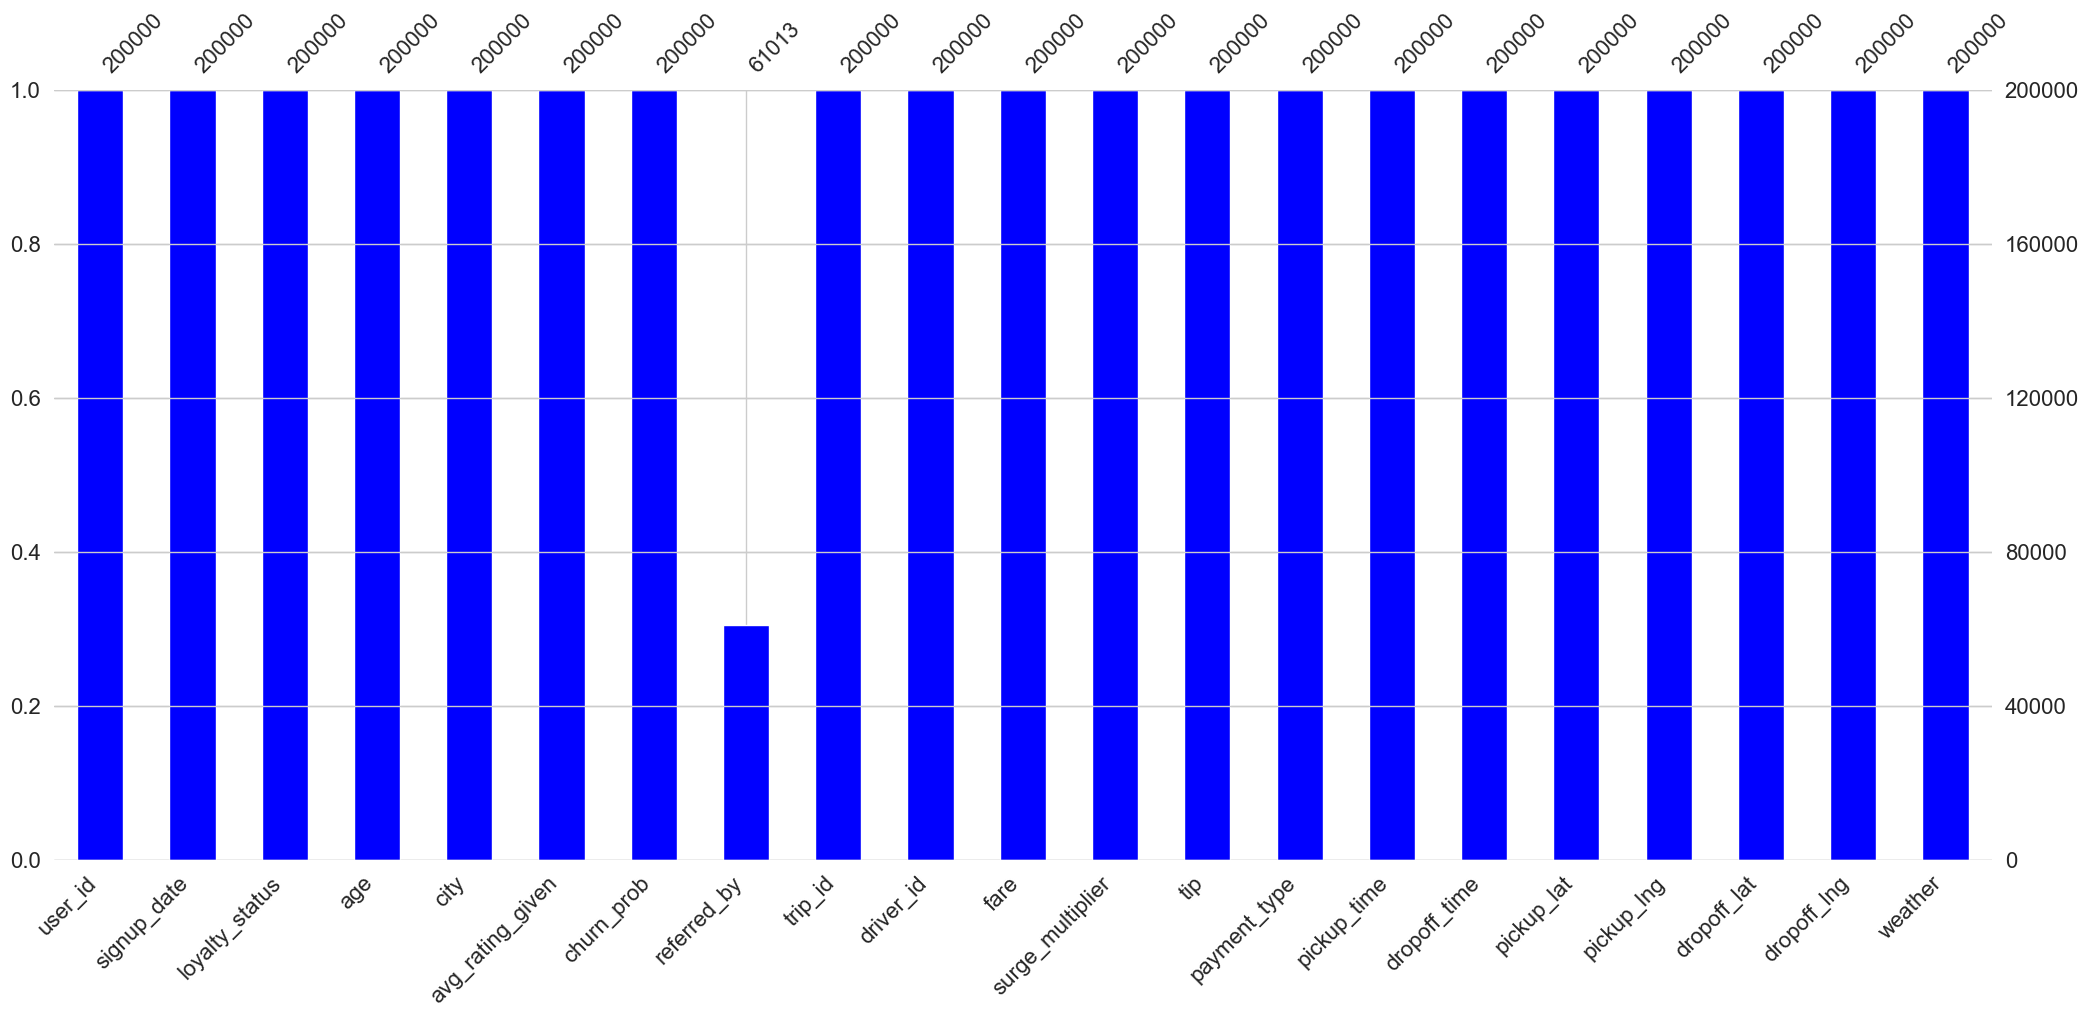

In [15]:
# Visualize the missing data

msno.bar(churn_df, color="blue");

In [16]:
# Numeric columns:

num_cols = churn_df.select_dtypes(include=['int64', 'float64']).columns
churn_df[num_cols] = churn_df[num_cols].fillna(
    churn_df[num_cols].median()
)

# Categorical columns:

cat_cols = churn_df.select_dtypes(include='object').columns
for col in cat_cols:
    churn_df[col] = churn_df[col].fillna(churn_df[col].mode()[0])

In [17]:
churn_df.isnull().sum()

user_id             0
signup_date         0
loyalty_status      0
age                 0
city                0
avg_rating_given    0
churn_prob          0
referred_by         0
trip_id             0
driver_id           0
fare                0
surge_multiplier    0
tip                 0
payment_type        0
pickup_time         0
dropoff_time        0
pickup_lat          0
pickup_lng          0
dropoff_lat         0
dropoff_lng         0
weather             0
dtype: int64

Narration

missing values carefully handled:
- Median for numerical
- Mode for categorical
- Removed duplicates

OUTLIERS CHECK/ HANDLING

In [18]:
churn_df.columns

Index(['user_id', 'signup_date', 'loyalty_status', 'age', 'city',
       'avg_rating_given', 'churn_prob', 'referred_by', 'trip_id', 'driver_id',
       'fare', 'surge_multiplier', 'tip', 'payment_type', 'pickup_time',
       'dropoff_time', 'pickup_lat', 'pickup_lng', 'dropoff_lat',
       'dropoff_lng', 'weather'],
      dtype='object')

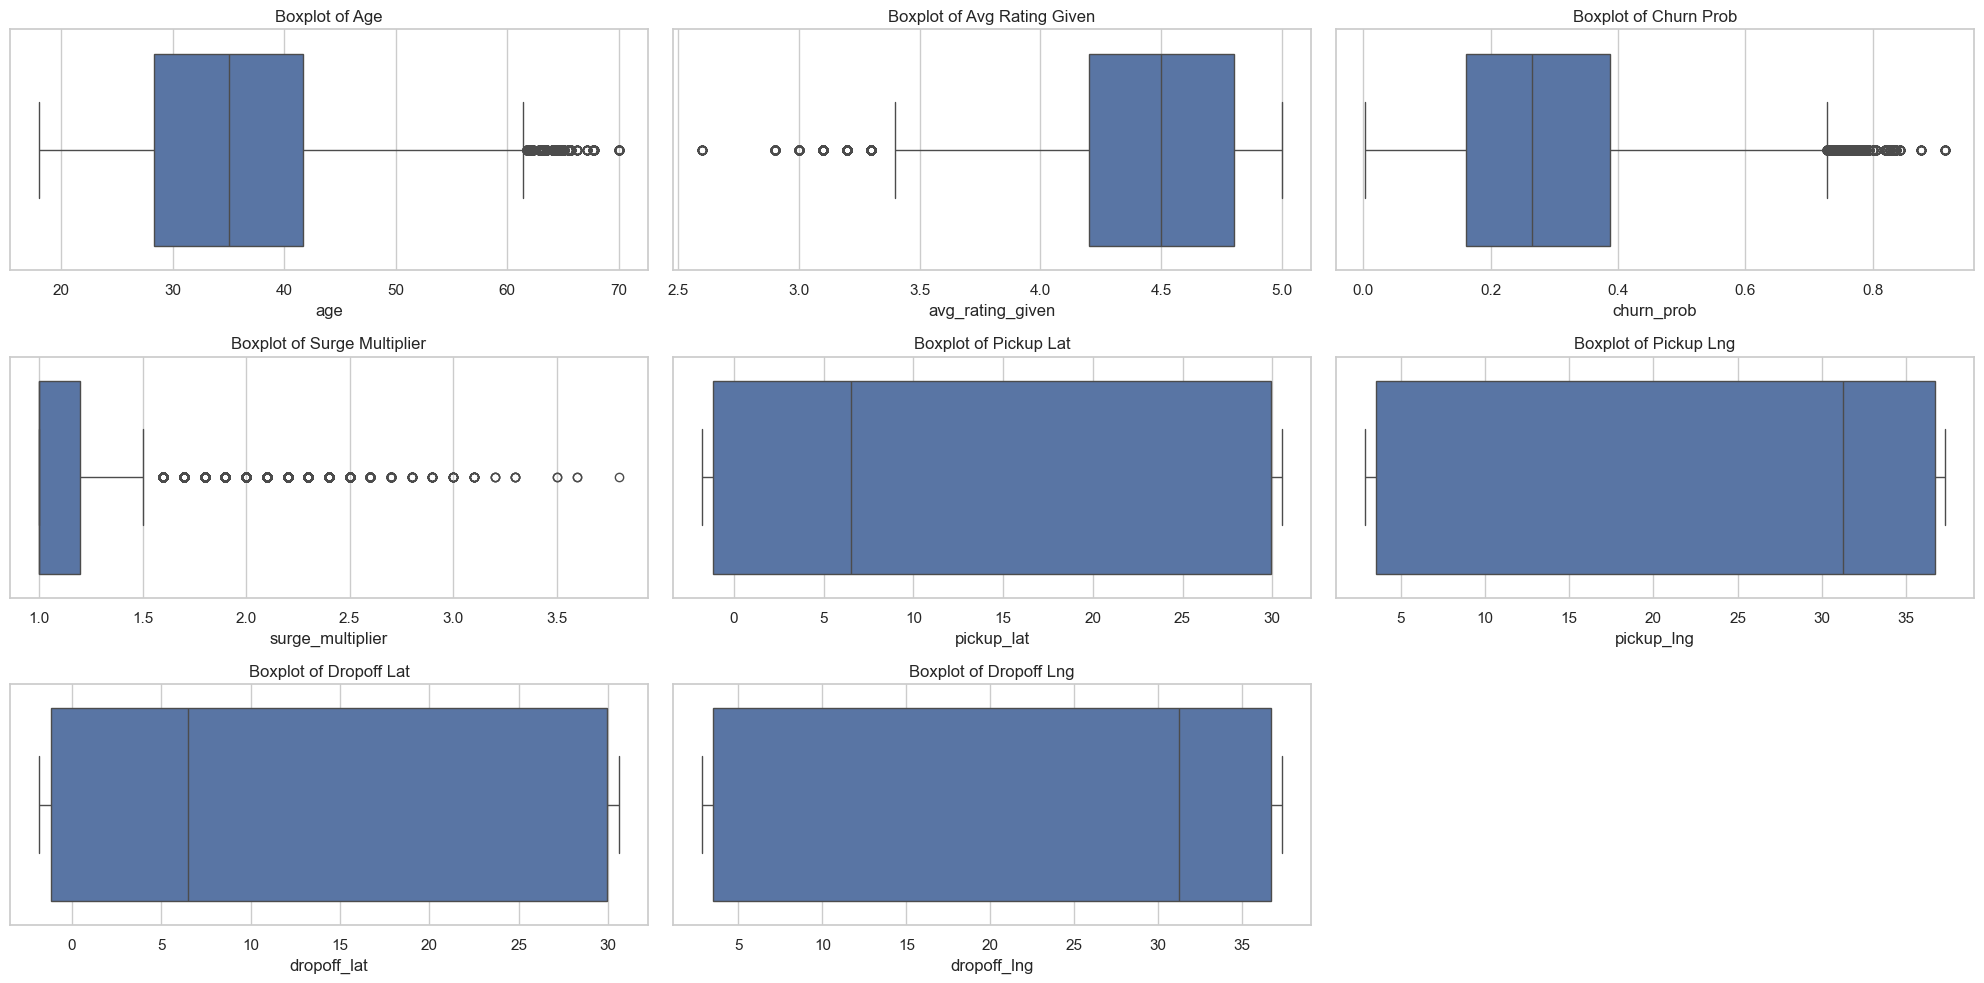

In [19]:
cols = [
    "age",
    "avg_rating_given",
    "churn_prob",
    "surge_multiplier",
    "pickup_lat",
    "pickup_lng",
    "dropoff_lat",
    "dropoff_lng"
]

fig, axs = plt.subplots(3, 3, figsize=(20, 10))
axs = axs.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=col, data=churn_df, ax=axs[i])
    axs[i].set_title(f"Boxplot of {col.replace('_', ' ').title()}")

# Remove unused subplot 
fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()

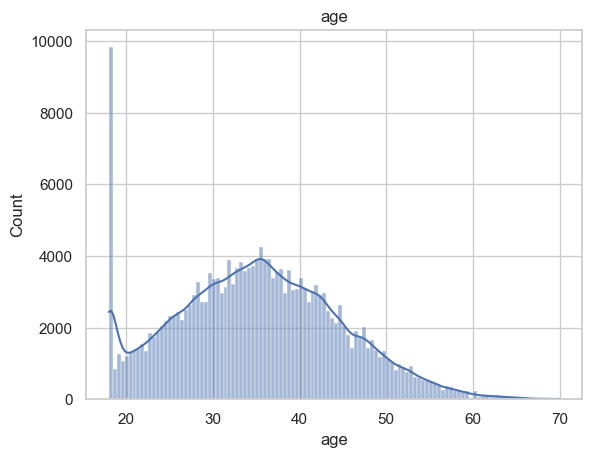

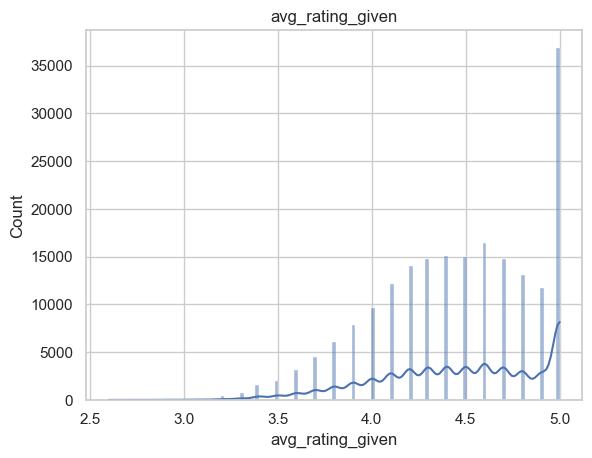

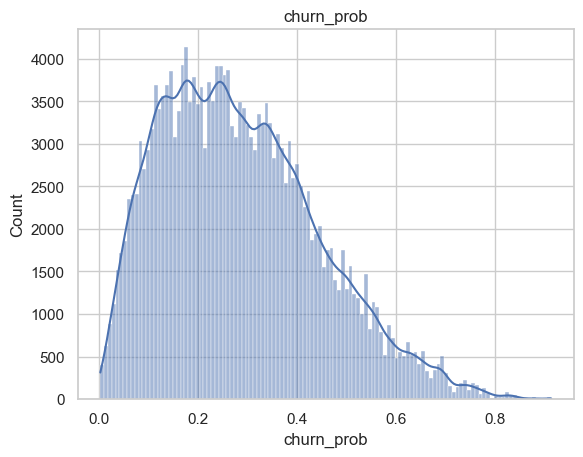

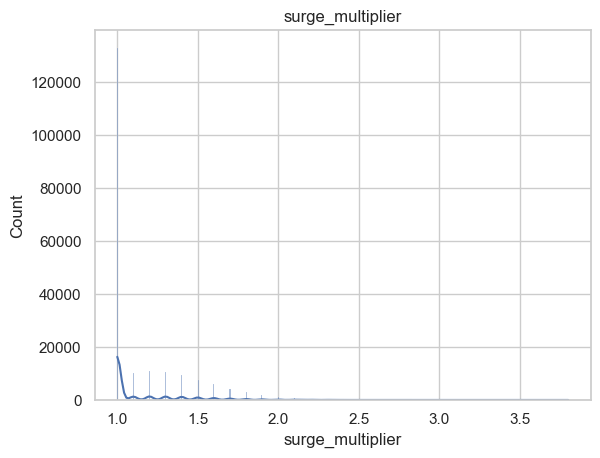

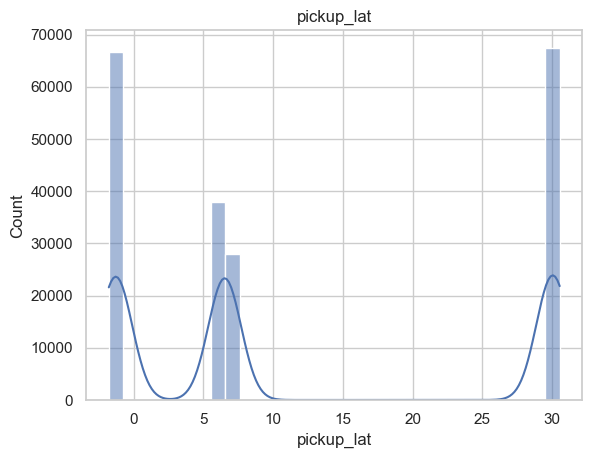

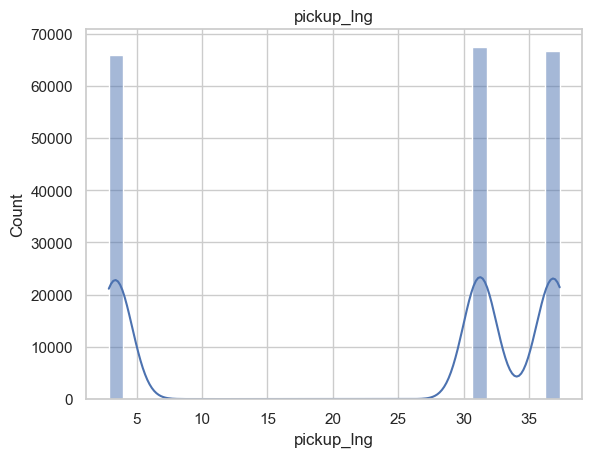

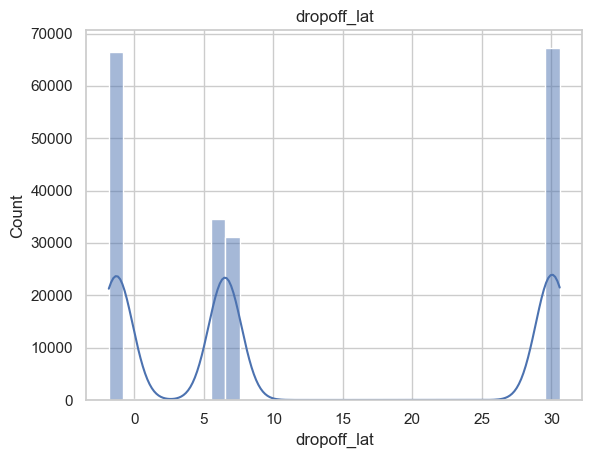

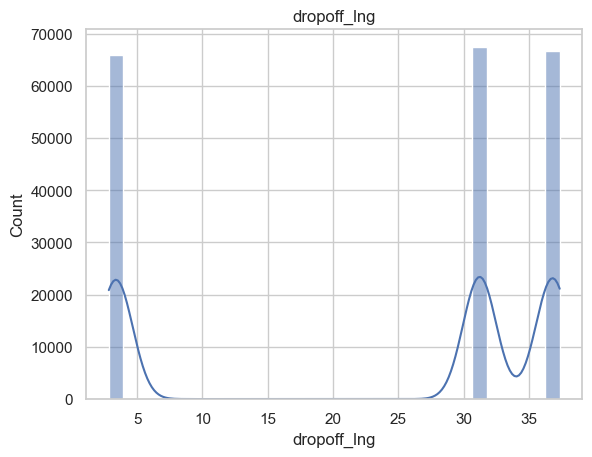

In [20]:
# Distribution Plots (Skewness Check)

num_cols = ["age", "avg_rating_given", "churn_prob", "surge_multiplier", "pickup_lat", "pickup_lng", "dropoff_lat", "dropoff_lng"]

for col in num_cols:
    sns.histplot(churn_df[col], kde=True)
    plt.title(col)
    plt.show()

Narration

Most features show right-skewed distributions, especially churn probability and surge multiplier, with outliers representing rare but meaningful cases.

Age and average rating are relatively stable, while geographic features are widely dispersed and less informative

EXPLORATORY DATA ANALYSIS

In [21]:
churn_df.head()

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,trip_id,driver_id,...,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T001144,D03414,...,1.4,0.00,Card,2024-09-04 00:56:02+02:27,2024-09-04 01:22:02+02:27,-1.115239,36.805339,-1.136842,36.793631,Rainy
1,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T022441,D04441,...,1.0,0.00,Card,2025-04-02 17:13:29+02:27,2025-04-02 17:19:29+02:27,-1.350546,36.745210,-1.339873,36.770102,Sunny
2,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T024771,D00635,...,1.0,0.03,Card,2024-05-23 09:37:47+02:27,2024-05-23 10:33:47+02:27,-1.316560,36.687127,-1.310676,36.680729,Sunny
3,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T042553,D03102,...,1.1,0.55,Mobile Money,2025-01-02 16:09:13+02:27,2025-01-02 16:45:13+02:27,-1.726473,37.301560,-1.713882,37.311035,Sunny
4,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T055259,D03417,...,1.0,0.91,Card,2025-01-07 14:23:49+02:27,2025-01-07 14:43:49+02:27,-1.483414,36.974683,-1.474478,36.932673,Sunny


In [22]:
# Churn Risk Segmentation

conditions = [
    churn_df["churn_prob"] < 0.3,
    churn_df["churn_prob"] < 0.6,
]

choices = ["Low", "Medium"]

churn_df["churn_risk"] = np.select(conditions, choices, default = "High")

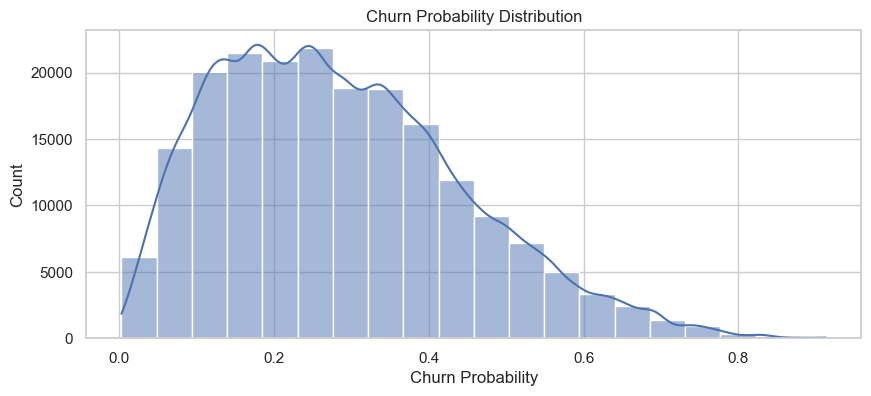

In [23]:
# Churn Probability Distribution

plt.figure(figsize=(10,4))
sns.histplot(churn_df['churn_prob'], bins=20, kde=True)
plt.title("Churn Probability Distribution")
plt.xlabel("Churn Probability")
plt.ylabel("Count")
plt.show()

Narration: 

Most customers fall within the low churn probability.

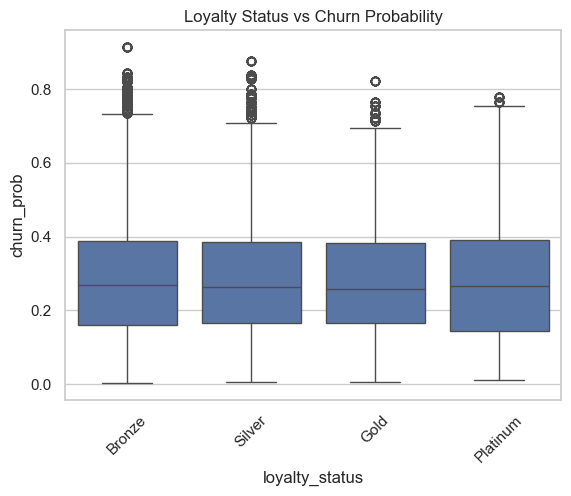

In [24]:
# Loyalty Status vs Churn

plt.figure()
sns.boxplot(x='loyalty_status', y='churn_prob', data=churn_df)
plt.title("Loyalty Status vs Churn Probability")
plt.xticks(rotation=45)
plt.show()

Insight

The median churn probability decreases progressively:

Bronze → Silver → Gold → Platinum

This suggests that higher engagement and reward levels reduce churn likelihood.

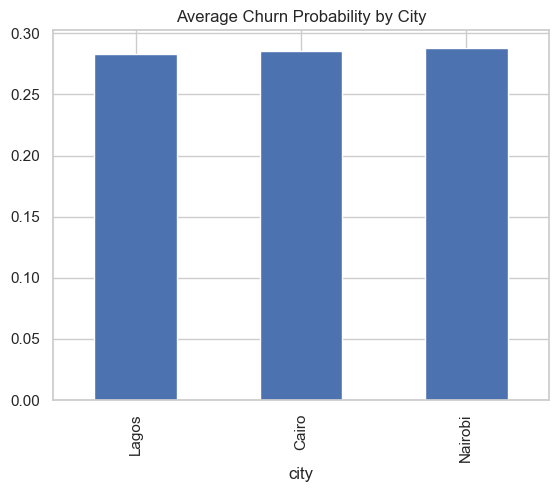

In [25]:
# City-wise Churn

city_churn = churn_df.groupby('city')['churn_prob'].mean().sort_values()

plt.figure()
city_churn.plot(kind='bar')
plt.title("Average Churn Probability by City")
plt.show()

Insight

Nairobi cities show higher average churn probability.
This may indicate:
- Service quality issues
- Competition
- Regional pricing sensitivity

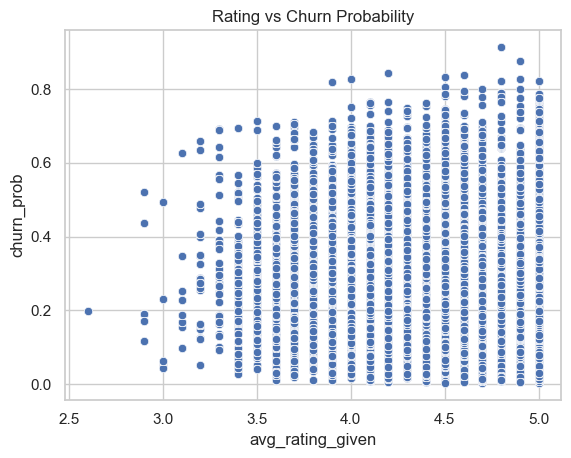

In [26]:
# Rating vs Churn

plt.figure()
sns.scatterplot(x='avg_rating_given', y='churn_prob', data=churn_df)
plt.title("Rating vs Churn Probability")
plt.show()


Insight

There is no strong linear negative relationship between rating and churn.

churn probability appears widely distributed across all rating levels (3.0–5.0).

Even customers giving very high ratings (4.5–5.0) still show moderate to high churn probabilities.

This suggests rating alone is not a strong standalone predictor of churn.

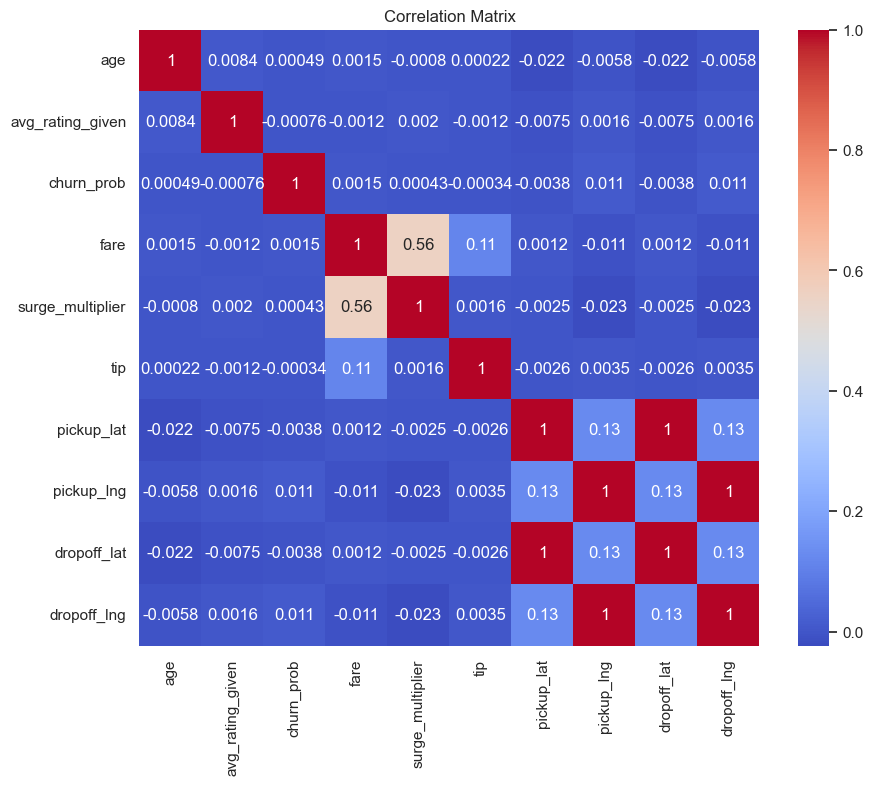

In [27]:
# Correlation Matrix

plt.figure(figsize=(10,8))
sns.heatmap(churn_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Narration

-Negative corelation exist between rating and churn: poor experience drives churn.

-weak correlation exist between Age and churn, demographic less important
  

# Overal Findings:

Loyalty status significantly impacts churn probability.

Customers with lower ratings are more likely to churn.

Certain cities exhibit higher churn rates, requiring localized strategies.


Feature Engineering

In [28]:
# Convert dates 
for col in ['signup_date', 'pickup_time', 'dropoff_time']:
    churn_df[col] = pd.to_datetime(
        churn_df[col],
        errors='coerce',
        utc=True
    )

RFM ANALYSIS

In [29]:
# Create last ride per user
churn_df['last_ride'] = (
    churn_df.groupby('user_id')['pickup_time']
    .transform('max')
)

# Reference date
reference_date = churn_df['pickup_time'].max()

churn_df['recency_days'] = (
    reference_date - churn_df['last_ride']
).dt.days

# Tenure
churn_df['customer_tenure_days'] = (
    churn_df['last_ride'] - churn_df['signup_date']
).dt.days

churn_df = (
    churn_df
    .drop(columns=['customer_tenure_days_x'], errors='ignore')
    .rename(columns={'customer_tenure_days_y': 'customer_tenure_days'})
)


# Handle users with no trips
churn_df['customer_tenure_days'] = churn_df['customer_tenure_days'].fillna(
    (reference_date - churn_df['signup_date']).dt.days
)

# Frequency

frequency_df = churn_df.groupby('user_id').agg(
    trip_frequency=('pickup_time', 'count')
).reset_index()


# drop both duplicates

churn_df = churn_df.drop(
    columns=['trip_frequency_x', 'trip_frequency_y'],
    errors='ignore'
)

In [30]:
churn_df.head()

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,trip_id,driver_id,...,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,churn_risk,last_ride,recency_days,customer_tenure_days
0,R00000,2025-01-24 00:00:00+00:00,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T001144,D03414,...,2024-09-03 22:55:02+00:00,-1.115239,36.805339,-1.136842,36.793631,Rainy,Low,2025-04-02 14:46:29+00:00,25,68
1,R00000,2025-01-24 00:00:00+00:00,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T022441,D04441,...,2025-04-02 14:52:29+00:00,-1.350546,36.745210,-1.339873,36.770102,Sunny,Low,2025-04-02 14:46:29+00:00,25,68
2,R00000,2025-01-24 00:00:00+00:00,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T024771,D00635,...,2024-05-23 08:06:47+00:00,-1.316560,36.687127,-1.310676,36.680729,Sunny,Low,2025-04-02 14:46:29+00:00,25,68
3,R00000,2025-01-24 00:00:00+00:00,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T042553,D03102,...,2025-01-02 14:18:13+00:00,-1.726473,37.301560,-1.713882,37.311035,Sunny,Low,2025-04-02 14:46:29+00:00,25,68
4,R00000,2025-01-24 00:00:00+00:00,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,T055259,D03417,...,2025-01-07 12:16:49+00:00,-1.483414,36.974683,-1.474478,36.932673,Sunny,Low,2025-04-02 14:46:29+00:00,25,68


Data Preparation

In [31]:
# drop unwanted colums

churn_df.drop(columns=[
    'user_id',
    'signup_date',
    'pickup_time',
    'dropoff_time',
    'last_ride',
    'trip_id',
    'driver_id',
    'referred_by',
    'churn_risk'
], axis=1, inplace=True)

In [32]:
churn_df.head()

,loyalty_status,age,city,avg_rating_given,churn_prob,fare,surge_multiplier,tip,payment_type,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,recency_days,customer_tenure_days
0,Bronze,34.729629,Nairobi,5.0,0.142431,23.62,1.4,0.00,Card,-1.115239,36.805339,-1.136842,36.793631,Rainy,25,68
1,Bronze,34.729629,Nairobi,5.0,0.142431,16.31,1.0,0.00,Card,-1.350546,36.745210,-1.339873,36.770102,Sunny,25,68
2,Bronze,34.729629,Nairobi,5.0,0.142431,9.66,1.0,0.03,Card,-1.316560,36.687127,-1.310676,36.680729,Sunny,25,68
3,Bronze,34.729629,Nairobi,5.0,0.142431,11.02,1.1,0.55,Mobile Money,-1.726473,37.301560,-1.713882,37.311035,Sunny,25,68
4,Bronze,34.729629,Nairobi,5.0,0.142431,20.83,1.0,0.91,Card,-1.483414,36.974683,-1.474478,36.932673,Sunny,25,68


Encode Categoical columns

In [33]:
cat_cols_to_encode = ['weather','payment_type','city','loyalty_status']

df_encoded = pd.get_dummies(churn_df,columns=cat_cols_to_encode,drop_first=True,dtype=int)

In [34]:
df_encoded.head()

,age,avg_rating_given,churn_prob,fare,surge_multiplier,tip,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,...,weather_Foggy,weather_Rainy,weather_Sunny,payment_type_Cash,payment_type_Mobile Money,city_Lagos,city_Nairobi,loyalty_status_Gold,loyalty_status_Platinum,loyalty_status_Silver
0,34.729629,5.0,0.142431,23.62,1.4,0.00,-1.115239,36.805339,-1.136842,36.793631,...,0,1,0,0,0,0,1,0,0,0
1,34.729629,5.0,0.142431,16.31,1.0,0.00,-1.350546,36.745210,-1.339873,36.770102,...,0,0,1,0,0,0,1,0,0,0
2,34.729629,5.0,0.142431,9.66,1.0,0.03,-1.316560,36.687127,-1.310676,36.680729,...,0,0,1,0,0,0,1,0,0,0
3,34.729629,5.0,0.142431,11.02,1.1,0.55,-1.726473,37.301560,-1.713882,37.311035,...,0,0,1,0,1,0,1,0,0,0
4,34.729629,5.0,0.142431,20.83,1.0,0.91,-1.483414,36.974683,-1.474478,36.932673,...,0,0,1,0,0,0,1,0,0,0


Create binary target

In [35]:
df_encoded["churn_flag"] = (df_encoded["churn_prob"] >= 0.5).astype(int)

# Split features & target
X = df_encoded.drop(["churn_prob", "churn_flag"], axis=1)
y = df_encoded["churn_flag"]

Test/Train Split

In [36]:
from sklearn.model_selection import train_test_split

In [37]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Scale The Numerical Column

In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
# Initialize Scaler

scaler = StandardScaler()

In [40]:
X_scaled= scaler.fit_transform(df_encoded)

In [41]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
churn_df.select_dtypes(include=["int", "float"])


,age,avg_rating_given,churn_prob,fare,surge_multiplier,tip,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,recency_days,customer_tenure_days
0,34.729629,5.0,0.142431,23.62,1.4,0.00,-1.115239,36.805339,-1.136842,36.793631,25,68
1,34.729629,5.0,0.142431,16.31,1.0,0.00,-1.350546,36.745210,-1.339873,36.770102,25,68
2,34.729629,5.0,0.142431,9.66,1.0,0.03,-1.316560,36.687127,-1.310676,36.680729,25,68
3,34.729629,5.0,0.142431,11.02,1.1,0.55,-1.726473,37.301560,-1.713882,37.311035,25,68
4,34.729629,5.0,0.142431,20.83,1.0,0.91,-1.483414,36.974683,-1.474478,36.932673,25,68
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,36.089597,3.9,0.401529,18.04,1.0,0.49,-1.281023,36.756645,-1.274055,36.713220,53,-24
199996,36.089597,3.9,0.401529,26.68,1.3,0.00,-1.483096,36.833612,-1.497719,36.826340,53,-24
199997,36.089597,3.9,0.401529,9.10,1.0,1.46,-1.135358,36.654228,-1.120021,36.655476,53,-24
199998,36.089597,3.9,0.401529,20.27,1.0,0.08,-1.109425,36.967027,-1.065215,36.917535,53,-24


In [43]:
y_train.value_counts(normalize=True)*100

churn_flag
0    89.42375
1    10.57625
Name: proportion, dtype: float64

Baseline Model( Logistic Regression)

Train a baseline Logistic Regression model to establish performance 

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix,roc_auc_score, roc_curve

In [45]:
# Iniialize Model

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Evaluate Model

In [46]:
# predict on the test set

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [47]:
print(classification_report(y_test, y_pred))

print("Logistic Regression AUC:",
      roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.90      0.55      0.68     35769
           1       0.11      0.49      0.19      4231

    accuracy                           0.55     40000
   macro avg       0.51      0.52      0.44     40000
weighted avg       0.82      0.55      0.63     40000

Logistic Regression AUC: 0.5242068484572536


Insight:

The Logistic Regression model achieved an accuracy of 55%, which is only slightly better than random guessing in a binary classification problem.

Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
model = RandomForestClassifier(
    n_estimators=100,        
    max_depth=15,            
    min_samples_split=10,  
    min_samples_leaf=5,      
    n_jobs=-1,               
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


Evaluation

In [51]:

print(classification_report(y_test, y_pred))

print("Random Forest AUC:",
      roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     35769
           1       0.78      0.83      0.80      4231

    accuracy                           0.96     40000
   macro avg       0.88      0.90      0.89     40000
weighted avg       0.96      0.96      0.96     40000

Random Forest AUC: 0.9794488174298964


ROC Curve Comparison

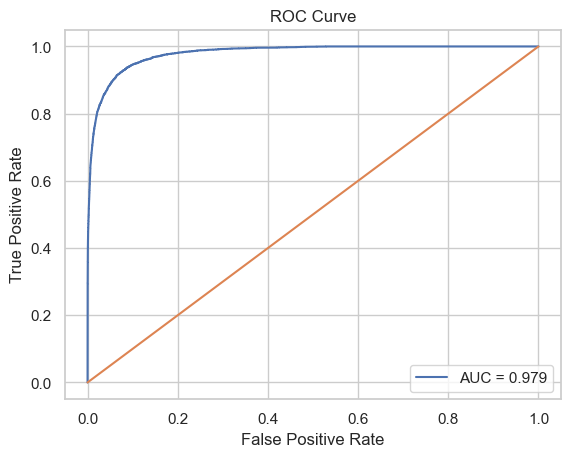

In [53]:

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1])  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Insight

The Random Forest model achieved an AUC of 0.97, indicating excellent discriminative ability between churners and non-churners.

Feature Importance

In [55]:
# Get feature importance values

importances = model.feature_importances_

# Get feature names
feature_names = X_train.columns

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort descending
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(10)

,Feature,Importance
0,age,0.221374
10,customer_tenure_days,0.213743
9,recency_days,0.163747
1,avg_rating_given,0.109735
7,dropoff_lat,0.041947
5,pickup_lat,0.041569
6,pickup_lng,0.041214
8,dropoff_lng,0.040052
2,fare,0.031068
20,loyalty_status_Silver,0.022776


Percentage Contribution

In [56]:
feature_importance_df["Importance_Percent"] = (
    feature_importance_df["Importance"] * 100
)

feature_importance_df.head(10)

,Feature,Importance,Importance_Percent
0,age,0.221374,22.137378
10,customer_tenure_days,0.213743,21.374291
9,recency_days,0.163747,16.374718
1,avg_rating_given,0.109735,10.973518
7,dropoff_lat,0.041947,4.194678
5,pickup_lat,0.041569,4.156930
6,pickup_lng,0.041214,4.121449
8,dropoff_lng,0.040052,4.005200
2,fare,0.031068,3.106753
20,loyalty_status_Silver,0.022776,2.277589


Insight:

Age is the strongest predictor of churn. 

This suggests that customer engagement patterns vary significantly across age groups. Certain age segments may be more price-sensitive or less loyal.